# Lead Conversion Prediction — Public Portfolio Notebook

**Business question:** *To what extent can a Machine Learning model improve lead qualification and prioritization in professional training?*

This notebook is the **public, confidentiality-preserving version** of an executed Databricks experiment.

### Publication boundary
The original work used internal prospect data. The public version intentionally does **not** expose:
- names, first names, email addresses, phone numbers or any direct identifier;
- row-level prospect records or individual lead scores;
- detailed conversion performance by acquisition channel, campaign or training offer;
- detailed model coefficients / modality-level feature weights that could reveal internal commercial information;
- the private Databricks table or original dataset.

Only methodology, aggregate dataset characteristics, aggregate model performance and non-identifying visualizations are published.

> The score is designed as **decision support**, not as an automated exclusion mechanism. Human review remains part of the intended process.

## 1. Imports
The experiment uses Pandas and scikit-learn inside Databricks. Spark is used only to access the private Databricks table; the modelling workload itself is not distributed because the final dataset contains only 383 observations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## 2. Modelling variables

Direct personal identifiers are excluded from the modelling perimeter.  
The published schema shows **variable families and technical column names only**, not any private row-level values.

In [ ]:
# Private source is deliberately not exposed in the public portfolio.
TABLE_NAME = "<private_catalog>.<private_schema>.<private_leads_table>"

categorical_features = [
    "annee_inscription", "mois_inscription", "pays_residence",
    "canal_acquisition", "campagne_base", "categorie_formation",
    "format_formation", "niveau_formation", "eligible_cpf",
    "mode_financement", "statut_professionnel", "formulaire_complete",
    "demande_brochure", "reponse_appel", "rendez_vous",
    "participation_webinaire"
]

numeric_features = [
    "duree_heures", "budget_estime_eur", "nb_clics_annonce",
    "nb_visites_site", "nb_relances", "delai_premier_contact_jours"
]

features = categorical_features + numeric_features
target = "conversion"

technical_columns = ["id_lead", "date_inscription", "partition_temporelle"]
columns_to_load = technical_columns + features + [target]

## 3. Private data loading

The internal dataset is not included in this repository. The following code documents the original loading pattern without exposing the source table or any rows.

In [ ]:
spark_df = spark.table(TABLE_NAME)

normalized_columns = [column.strip().lower() for column in spark_df.columns]
spark_df = spark_df.toDF(*normalized_columns)

missing_columns = [
    column for column in columns_to_load
    if column not in spark_df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = spark_df.select(*columns_to_load).toPandas()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# PUBLIC PORTFOLIO RULE:
# Do not display df.head(), individual IDs, exact dates or row-level prospect data.

## 4. Cleaning and leakage controls

The preparation phase:
- deduplicates leads on the technical ID;
- normalizes dates, categories and numeric fields;
- restricts the target to `{0, 1}`;
- standardizes temporal partitions;
- keeps identification fields outside the predictive feature vector;
- excludes information that would only be known after the commercial outcome.

In [ ]:
initial_rows = len(df)

# Nettoyage de l'identifiant
df["id_lead"] = (
    df["id_lead"]
    .astype(str)
    .str.strip()
)

# Suppression des doublons
df = (
    df
    .drop_duplicates(
        subset=["id_lead"],
        keep="first"
    )
    .copy()
)

# Conversion de la date
df["date_inscription"] = pd.to_datetime(
    df["date_inscription"],
    errors="coerce"
)

# Nettoyage des variables catégorielles
for column in categorical_features:
    df[column] = (
        df[column]
        .astype(object)
        .apply(
            lambda value:
            value.strip()
            if isinstance(value, str)
            else value
        )
    )

    df[column] = df[column].replace(
        {
            "": np.nan,
            "nan": np.nan,
            "None": np.nan
        }
    )

# Année et mois traités comme catégories
for column in ["annee_inscription", "mois_inscription"]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    df[column] = df[column].apply(
        lambda value:
        str(int(value))
        if pd.notna(value)
        else np.nan
    )

# Conversion des variables numériques
for column in numeric_features:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    # Les valeurs négatives sont considérées comme incohérentes
    df.loc[df[column] < 0, column] = np.nan

# Conversion de la cible
df[target] = pd.to_numeric(
    df[target],
    errors="coerce"
)

# Conservation des cibles 0 et 1
df = df[
    df[target].isin([0, 1])
].copy()

df[target] = df[target].astype(int)

# Normalisation de la partition
df["partition_temporelle"] = (
    df["partition_temporelle"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "entraînement": "train",
        "entrainement": "train",
        "training": "train",
        "validation": "validation",
        "évaluation": "validation",
        "evaluation": "validation",
        "test": "test"
    })
)

# Conservation des partitions valides
df = df[
    df["partition_temporelle"].isin(
        ["train", "validation", "test"]
    )
].copy()

print("Lignes avant nettoyage :", initial_rows)
print("Lignes après nettoyage :", len(df))
print("Identifiants uniques :", df["id_lead"].nunique())

## 5. Data quality

One important limitation surfaced during execution: `budget_estime_eur` became unusable because its textual formatting produced 100% missing values after numeric conversion. The experiment deliberately preserves this limitation instead of hiding it; the model results therefore rely on the remaining usable variables.

In [ ]:
missing_values = (
    df[features + [target]]
    .isna()
    .sum()
    .reset_index()
)

missing_values.columns = [
    "variable",
    "nombre_valeurs_manquantes"
]

missing_values["pourcentage"] = (
    missing_values["nombre_valeurs_manquantes"]
    / len(df)
    * 100
)

missing_values = missing_values.sort_values(
    by="nombre_valeurs_manquantes",
    ascending=False
)

display(missing_values)

variable,nombre_valeurs_manquantes,pourcentage
budget_estime_eur,383,100.0
annee_inscription,0,0.0
demande_brochure,0,0.0
delai_premier_contact_jours,0,0.0
nb_relances,0,0.0
nb_visites_site,0,0.0
nb_clics_annonce,0,0.0
duree_heures,0,0.0
participation_webinaire,0,0.0
rendez_vous,0,0.0


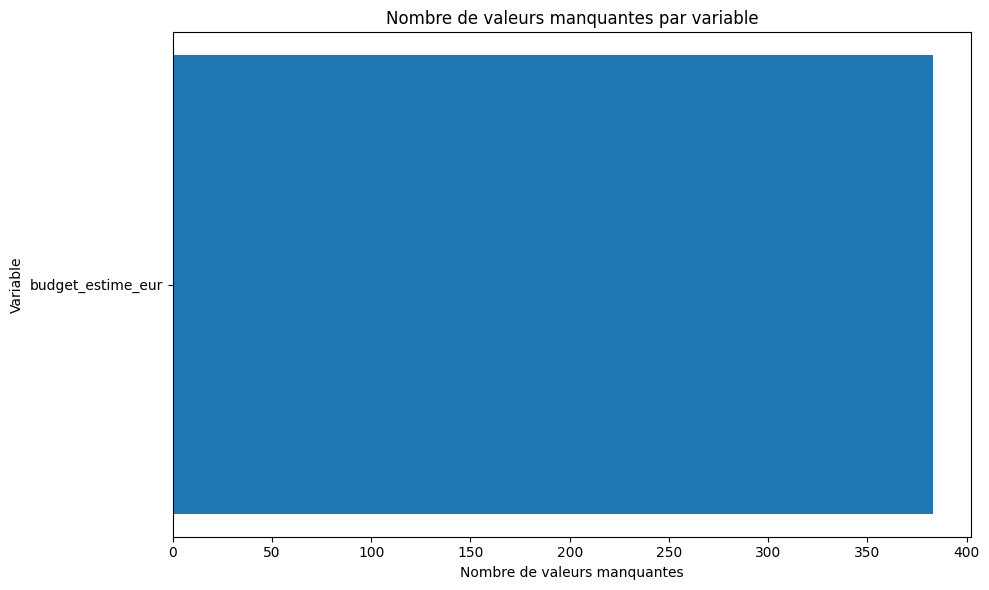

In [ ]:
missing_to_plot = missing_values[
    missing_values["nombre_valeurs_manquantes"] > 0
].copy()

if len(missing_to_plot) > 0:

    plt.figure(figsize=(10, 6))

    plt.barh(
        missing_to_plot["variable"],
        missing_to_plot["nombre_valeurs_manquantes"]
    )

    plt.title("Nombre de valeurs manquantes par variable")
    plt.xlabel("Nombre de valeurs manquantes")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

else:
    print(
        "Aucune valeur manquante détectée "
        "dans les variables sélectionnées."
    )

## 6. Target distribution

The final modelling dataset contains **383 leads**:
- **261 non-converted** leads (68.15%)
- **122 converted** leads (31.85%)

The positive class is therefore a minority class, which is why model assessment does not rely on accuracy alone.

In [ ]:
target_distribution = (
    df[target]
    .value_counts()
    .sort_index()
    .rename_axis("conversion")
    .reset_index(name="nombre")
)

target_distribution["libelle"] = (
    target_distribution["conversion"]
    .map({
        0: "Non converti",
        1: "Converti"
    })
)

target_distribution["pourcentage"] = (
    target_distribution["nombre"]
    / len(df)
    * 100
)

display(target_distribution)

conversion,nombre,libelle,pourcentage
0,261,Non converti,68.1462140992167
1,122,Converti,31.853785900783286


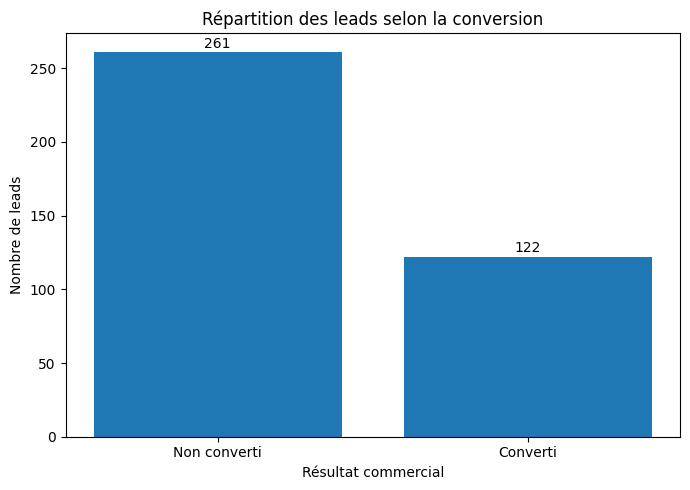

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    target_distribution["libelle"],
    target_distribution["nombre"]
)

plt.title("Répartition des leads selon la conversion")
plt.xlabel("Résultat commercial")
plt.ylabel("Nombre de leads")

for index, value in enumerate(
    target_distribution["nombre"]
):
    plt.text(
        index,
        value + 3,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Confidential exploratory analysis boundary

Internal exploratory analyses were performed by acquisition channel, financing mode, training category and other commercial dimensions. Their detailed values are **not published** because they could reveal internal campaign effectiveness and commercially sensitive information.

The public portfolio therefore focuses on the target balance, data partitions, model methodology, aggregate validation/test performance, aggregate confusion matrices and business interpretation at cohort level.

## 8. Temporal train / validation / test split

The experiment uses predefined temporal partitions rather than a single random split:
- **Train:** 230 leads, 77 conversions
- **Validation:** 77 leads, 22 conversions
- **Test:** 76 leads, 23 conversions

The test set is not used to choose the model.

In [ ]:
partition_summary = (
    df.groupby("partition_temporelle")
    .agg(
        nombre_leads=("id_lead", "count"),
        conversions=("conversion", "sum"),
        taux_conversion=("conversion", "mean")
    )
    .reset_index()
)

partition_summary["taux_conversion"] = (
    partition_summary["taux_conversion"]
    * 100
)

display(partition_summary)

partition_temporelle,nombre_leads,conversions,taux_conversion
test,76,23,30.263157894736842
train,230,77,33.47826086956522
validation,77,22,28.57142857142857


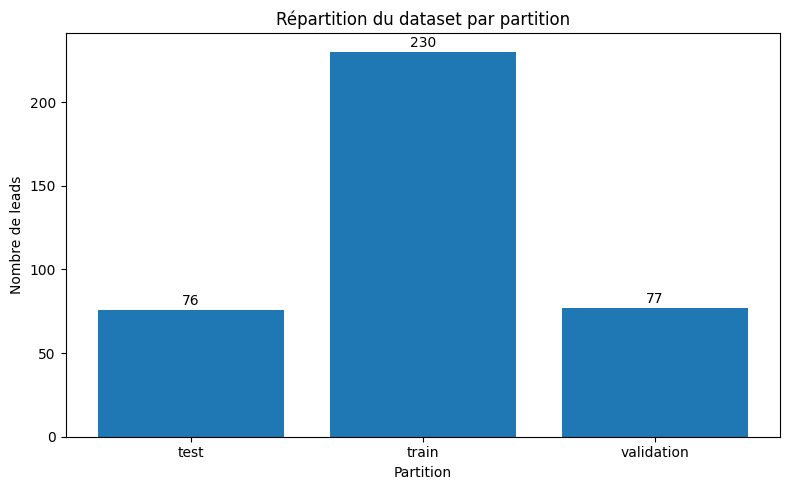

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    partition_summary["partition_temporelle"],
    partition_summary["nombre_leads"]
)

plt.title("Répartition du dataset par partition")
plt.xlabel("Partition")
plt.ylabel("Nombre de leads")

for index, value in enumerate(
    partition_summary["nombre_leads"]
):
    plt.text(
        index,
        value + 3,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
train_df = df[
    df["partition_temporelle"] == "train"
].copy()

validation_df = df[
    df["partition_temporelle"] == "validation"
].copy()

test_df = df[
    df["partition_temporelle"] == "test"
].copy()

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Entraînement :", X_train.shape)
print("Validation :", X_validation.shape)
print("Test :", X_test.shape)

Entraînement : (230, 22)
Validation : (77, 22)
Test : (76, 22)


## 9. Preprocessing pipeline

Categorical features are imputed with the most frequent category and One-Hot Encoded. Numeric features are median-imputed and standardized. The same preprocessing logic is used for all models so that the comparison remains consistent.

In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputation",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encodage",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputation",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "standardisation",
            StandardScaler()
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "variables_categorielles",
            categorical_pipeline,
            categorical_features
        ),
        (
            "variables_numeriques",
            numeric_pipeline,
            numeric_features
        )
    ],
    remainder="drop"
)

print("Pipeline de préparation créé.")

Pipeline de préparation créé.


## 10. Candidate models

Three deliberately simple models are compared: Logistic Regression, Decision Tree and Random Forest. Balanced class weights are used to give more importance to the converted class.

In [ ]:
models = {
    "Regression_logistique": LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Arbre_decision": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random_Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=1,
        random_state=42
    )
}

print("Modèles définis :", list(models.keys()))

Modèles définis : ['Regression_logistique', 'Arbre_decision', 'Random_Forest']


## 11. Validation results

The model is chosen on the validation set, not on the final test set. No single model dominates every metric, so the selection is based on the intended business use: identify converted leads while retaining an interpretable probability score.

In [ ]:
results = []
trained_models = {}

for model_name, estimator in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                clone(preprocessor)
            ),
            (
                "model",
                clone(estimator)
            )
        ]
    )

    # Entraînement
    pipeline.fit(
        X_train,
        y_train
    )

    # Probabilités de conversion
    validation_probabilities = (
        pipeline.predict_proba(
            X_validation
        )[:, 1]
    )

    # Prédictions avec un seuil de 0,50
    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        validation_predictions,
        labels=[0, 1]
    ).ravel()

    results.append({
        "modele": model_name,
        "accuracy": accuracy_score(
            y_validation,
            validation_predictions
        ),
        "precision": precision_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            validation_probabilities
        ),
        "pr_auc": average_precision_score(
            y_validation,
            validation_probabilities
        ),
        "vrais_positifs": tp,
        "faux_positifs": fp,
        "faux_negatifs": fn,
        "vrais_negatifs": tn
    })

    trained_models[model_name] = {
        "pipeline": pipeline,
        "probabilities": validation_probabilities,
        "predictions": validation_predictions
    }

comparison_df = (
    pd.DataFrame(results)
    .sort_values(
        by=["pr_auc", "f1_score"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(comparison_df.round(3))

/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy

modele,accuracy,precision,recall,f1_score,roc_auc,pr_auc,vrais_positifs,faux_positifs,faux_negatifs,vrais_negatifs
Regression_logistique,0.532,0.306,0.5,0.379,0.537,0.389,11,25,11,30
Random_Forest,0.623,0.348,0.364,0.356,0.604,0.382,8,15,14,40
Arbre_decision,0.468,0.289,0.591,0.388,0.467,0.277,13,32,9,23


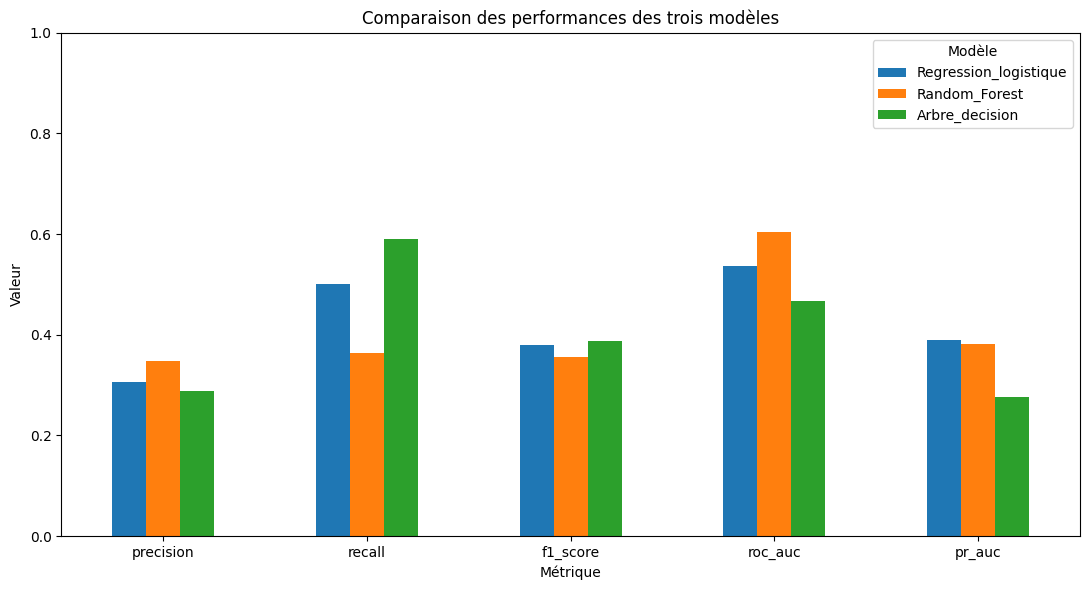

In [ ]:
metrics_to_plot = [
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]

comparison_plot = (
    comparison_df
    .set_index("modele")[metrics_to_plot]
    .T
)

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparaison des performances des trois modèles")
plt.xlabel("Métrique")
plt.ylabel("Valeur")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Modèle")

plt.tight_layout()
plt.show()

### ROC curves
Random Forest has the highest validation ROC-AUC, but ROC-AUC is not the only decision criterion for this imbalanced lead-prioritization problem.

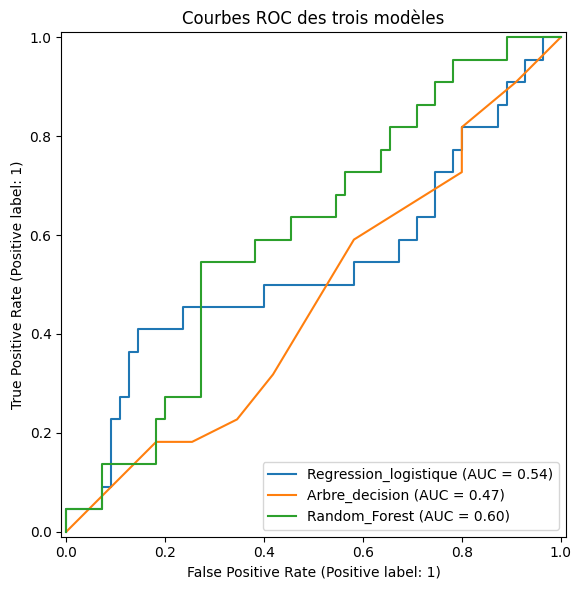

In [ ]:
plt.figure(figsize=(8, 6))

axis = plt.gca()

for model_name, model_data in trained_models.items():

    RocCurveDisplay.from_predictions(
        y_validation,
        model_data["probabilities"],
        name=model_name,
        ax=axis
    )

plt.title("Courbes ROC des trois modèles")
plt.tight_layout()
plt.show()

### Precision–Recall curves
Logistic Regression achieves the best validation PR-AUC (0.389), slightly ahead of Random Forest (0.382), while providing higher recall than Random Forest at the 0.50 threshold.

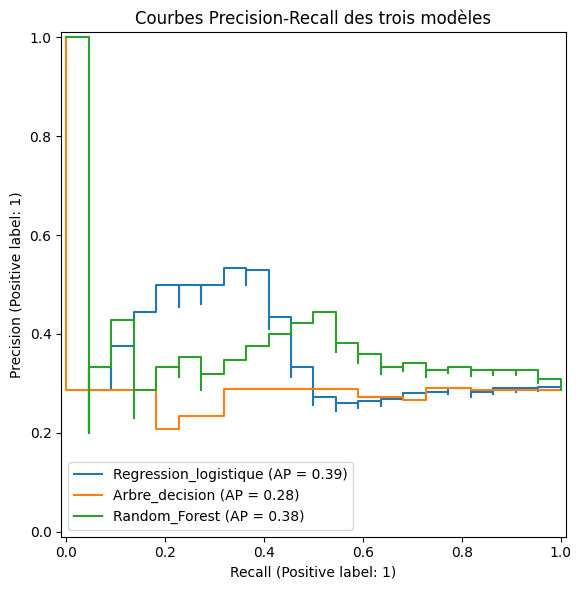

In [ ]:
plt.figure(figsize=(8, 6))

axis = plt.gca()

for model_name, model_data in trained_models.items():

    PrecisionRecallDisplay.from_predictions(
        y_validation,
        model_data["probabilities"],
        name=model_name,
        ax=axis
    )

plt.title("Courbes Precision-Recall des trois modèles")
plt.tight_layout()
plt.show()

### Validation confusion matrices
At threshold 0.50, Logistic Regression detects 11 of 22 conversions; Random Forest detects 8; Decision Tree detects 13 but generates more false positives. The business cost of these errors is asymmetric.

<Figure size 600x500 with 0 Axes>

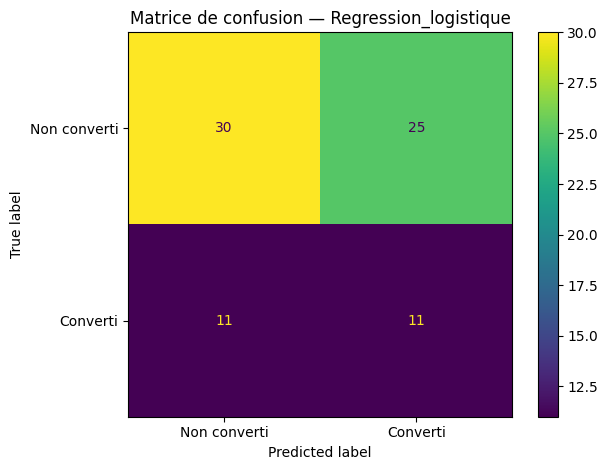

<Figure size 600x500 with 0 Axes>

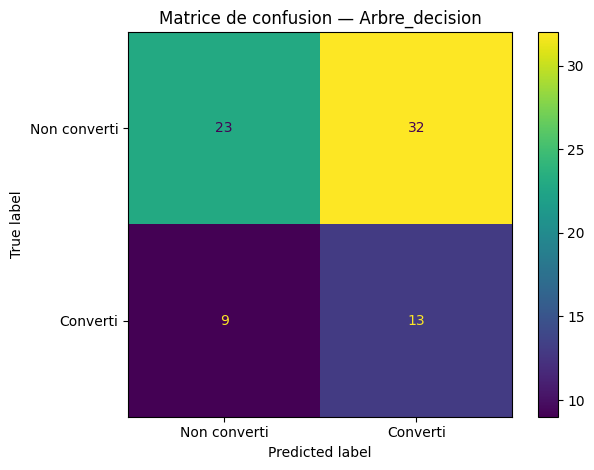

<Figure size 600x500 with 0 Axes>

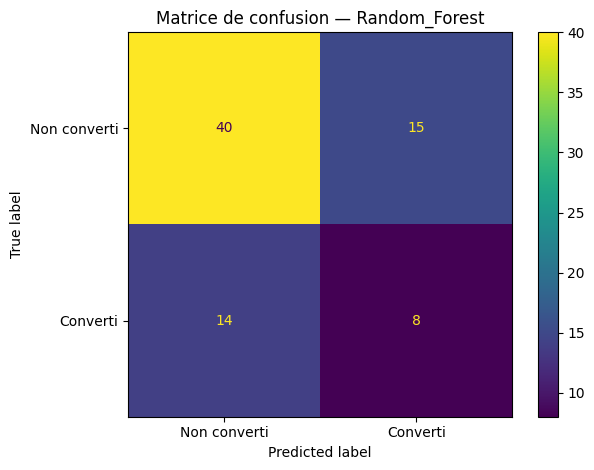

In [ ]:
for model_name, model_data in trained_models.items():

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        model_data["predictions"],
        display_labels=[
            "Non converti",
            "Converti"
        ]
    )

    plt.title(
        f"Matrice de confusion — {model_name}"
    )

    plt.tight_layout()
    plt.show()

## 12. Champion selection: Logistic Regression

Logistic Regression is retained because it offers the most coherent compromise for this prototype:
- best validation PR-AUC: **0.389**;
- validation recall: **0.500**, above Random Forest;
- directly usable conversion probability;
- simpler explanation to business users.

The choice is contextual; it does not imply that Logistic Regression is universally superior.

In [ ]:
best_model_name = comparison_df.loc[
    0,
    "modele"
]

print(
    "Meilleur modèle sur les données de validation :",
    best_model_name
)

display(
    comparison_df.head(1)
)

Meilleur modèle sur les données de validation : Regression_logistique


modele,accuracy,precision,recall,f1_score,roc_auc,pr_auc,vrais_positifs,faux_positifs,faux_negatifs,vrais_negatifs
Regression_logistique,0.5324675324675324,0.3055555555555556,0.5,0.3793103448275862,0.5371900826446282,0.3891440457821404,11,25,11,30


## 13. Final retraining and one-time test evaluation

After model selection, training and validation data are combined (307 leads) and the selected model is retrained. The 76-lead test set is then used once for final evaluation.

In [ ]:
train_validation_df = pd.concat(
    [
        train_df,
        validation_df
    ],
    ignore_index=True
)

X_train_final = train_validation_df[features]
y_train_final = train_validation_df[target]

final_model = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(preprocessor)
        ),
        (
            "model",
            clone(
                models[best_model_name]
            )
        )
    ]
)

final_model.fit(
    X_train_final,
    y_train_final
)

print(
    "Modèle final réentraîné :",
    best_model_name
)

Modèle final réentraîné : Regression_logistique


/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
test_probabilities = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
).ravel()

final_results = pd.DataFrame([{
    "modele_final": best_model_name,
    "accuracy_test": accuracy_score(
        y_test,
        test_predictions
    ),
    "precision_test": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "recall_test": recall_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "f1_test": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "roc_auc_test": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "pr_auc_test": average_precision_score(
        y_test,
        test_probabilities
    ),
    "vrais_positifs": tp,
    "faux_positifs": fp,
    "faux_negatifs": fn,
    "vrais_negatifs": tn
}])

display(final_results.round(3))

/databricks/python/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['budget_estime_eur']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


modele_final,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,pr_auc_test,vrais_positifs,faux_positifs,faux_negatifs,vrais_negatifs
Regression_logistique,0.684,0.484,0.652,0.556,0.704,0.501,15,16,8,37


### Final test confusion matrix

At threshold 0.50, the final test matrix contains 37 true negatives, 16 false positives, 8 false negatives and 15 true positives. The **8 false negatives** are especially important for the use case because these are actual conversions that would not have been prioritized at the reference threshold.

<Figure size 600x500 with 0 Axes>

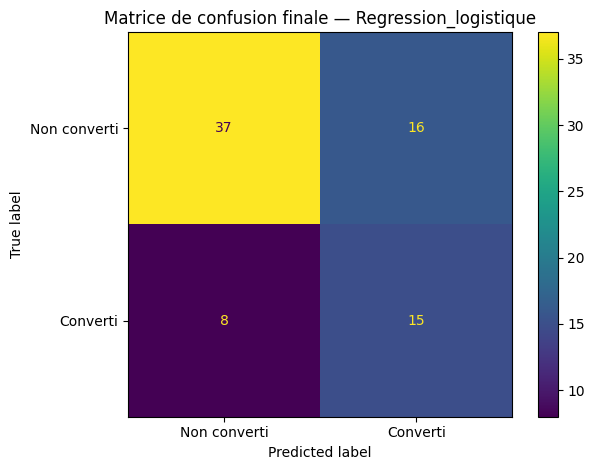

In [ ]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "Non converti",
        "Converti"
    ]
)

plt.title(
    f"Matrice de confusion finale — {best_model_name}"
)

plt.tight_layout()
plt.show()

## 14. Business interpretation

On the 76-lead test set:
- baseline conversion rate = **30.3%** (23/76);
- 31 leads are predicted positive at threshold 0.50;
- 15 of those 31 actually convert;
- prioritized-group conversion rate = **48.4%**;
- relative concentration / lift ≈ **1.6×**;
- recall = **65.2%**.

The result is promising as a ranking prototype, but it does **not** prove that using the score causes a higher conversion rate. That requires a prospective operational pilot.

## 15. Public confidentiality boundary for interpretability

The private experiment computes transformed-feature importance / coefficient magnitude and individual lead scores. Those detailed outputs are intentionally excluded from the public notebook because they can reveal campaign-specific behaviour, geography-specific effects, internal commercial patterns or individual prospect ranking.

The public portfolio documents **feature families and methodology**, not modality-level weights.

## 16. From probability to operational priority

The intended operational pattern is:
1. calculate a conversion probability;
2. use it to **order** leads;
3. choose a working threshold according to commercial capacity and the relative cost of false negatives vs false positives;
4. keep a human decision-maker in the loop;
5. monitor performance on new cohorts.

A score should not automatically exclude low-ranked prospects.

## 17. Limitations

This is a **proof of concept**, not a production-ready model.

Main limitations:
- only 383 observations;
- validation and test contain 77 and 76 leads respectively;
- model metrics are sensitive to partition composition;
- `budget_estime_eur` was unusable in this run;
- threshold 0.50 was not calibrated to a measured business cost;
- limited hyperparameter optimization;
- predictive associations are not causal effects;
- no prospective test has yet established that score-assisted prioritization improves commercial outcomes.

## 18. Next validation step

The next step is an operational pilot on new cohorts: compare the existing commercial process with a score-assisted prioritization process, define the threshold before observing outcomes, monitor business and predictive metrics, and recalibrate or retrain only when justified.

This is the missing evidence needed to move from **historical ranking performance** to **measurable business impact**.

## 19. Privacy / GDPR note

This repository uses a **data-minimization-by-publication** approach:
- the original row-level dataset is not published;
- direct identifiers are not published;
- pseudonymous technical IDs and exact prospect-level scores are not published;
- only aggregate, non-identifying results necessary to explain the experiment are shared.

This public portfolio is designed to reduce re-identification and business-confidentiality risk. It is not a legal certification of the underlying organizational processing.